# Specimen 01 — MNIST Digit Recognition

Goal: your first neural net. Write the training loop by hand before reaching for shortcuts — the point of this specimen is seeing backprop happen, not abstracting it away.

In [ ]:
#Torch contains a number of classes and functions that can be used to build neural networks. The most important class is torch.nn.Module, which is the base class for all neural network modules in PyTorch. A module can contain other modules, allowing for the creation of complex architectures.
import torch
import torch.nn as nn
#Functional API provides a number of functions that can be used to build neural networks. These functions are stateless and can be used to define the forward pass of a network. The most important function is torch.nn.functional, which contains a number of functions for building neural networks.
import torch.nn.functional as F
#Utils contains a number of utility functions that can be used to build neural networks. The most important function is torch.utils.data.DataLoader, which can be used to load data in batches.
from torch.utils.data import DataLoader
#Vision contains a number of classes and functions that can be used to build computer vision models. The most important class is torchvision.models, which contains a number of pre-trained models that can be used for transfer learning.
import torchvision
#Transforms contains a number of classes and functions that can be used to perform data augmentation and preprocessing. The most important class is torchvision.transforms, which contains a number of functions for performing common image transformations.
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Set device
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
#Using device: mps
print('Using device:', device)


Using device: mps


## 1. Load & inspect

`torchvision.datasets.MNIST`. Check image shape, pixel value range, and class balance across the 10 digits.

In [ ]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

# Load the MNIST dataset, which is a dataset of handwritten digits. The dataset contains 60,000 training images and 10,000 test images. Each image is a 28x28 grayscale image, and the labels are the digits 0-9.
train_raw = torchvision.datasets.MNIST(root='./data', train=True, download=True)
test_raw = torchvision.datasets.MNIST(root='./data', train=False, download=True)

# Print the shape of the training and test datasets, as well as the minimum and maximum pixel values in the training dataset, and the number of samples for each class in the training dataset.
print(train_raw.data.shape, test_raw.data.shape)
print(train_raw.data.min().item(), train_raw.data.max().item())
print(torch.bincount(train_raw.targets))


  0%|          | 0.00/9.91M [00:00<?, ?B/s]


  1%|          | 98.3k/9.91M [00:00<00:17, 568kB/s]


  4%|▍         | 426k/9.91M [00:00<00:07, 1.34MB/s]


 10%|▉         | 983k/9.91M [00:00<00:03, 2.68MB/s]


 20%|██        | 2.00M/9.91M [00:00<00:01, 4.51MB/s]

...


 89%|████████▉ | 1.47M/1.65M [00:00<00:00, 3.38MB/s]


100%|██████████| 1.65M/1.65M [00:00<00:00, 2.80MB/s]


  0%|          | 0.00/4.54k [00:00<?, ?B/s]


100%|██████████| 4.54k/4.54k [00:00<00:00, 7.11MB/s]

torch.Size([60000, 28, 28]) torch.Size([10000, 28, 28])
0 255
tensor([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949])


## 2. Preprocess & batch

Normalize pixel values, wrap in a `DataLoader` with a sensible batch size.

In [ ]:
# Define a transform to normalize the data. The MNIST dataset contains grayscale images with pixel values in the range [0, 255]. We will normalize the pixel values to the range [0, 1] and then standardize them to have a mean of 0.1307 and a standard deviation of 0.3081, which are the mean and standard deviation of the MNIST dataset.
transform = transforms.Compose([
    #Convert the image to a tensor and normalize the pixel values to the range [0, 1] because the pixel values are in the range [0, 255].
    transforms.ToTensor(),
    #Standardize the pixel values to have a mean of 0.1307 and a standard deviation of 0.3081.
    transforms.Normalize((0.1307,), (0.3081,))
])

# Load the MNIST dataset again, this time applying the transform defined above. We will also split the training dataset into a training set and a validation set. The validation set will contain 6,000 samples, and the training set will contain the remaining 54,000 samples. We will use a batch size of 128 for the data loaders.
train_full = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Split the training dataset into a training set and a validation set. The validation set will contain 6,000 samples, and the training set will contain the remaining 54,000 samples. We will use a batch size of 128 for the data loaders.
val_size = 6000
train_size = len(train_full) - val_size
train_dataset, val_dataset = torch.utils.data.random_split(
    train_full, [train_size, val_size], generator=torch.Generator().manual_seed(42)
)

# Define data loaders for the training, validation, and test datasets. We will use a batch size of 128 for the data loaders. The training data loader will shuffle the data, while the validation and test data loaders will not shuffle the data.
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Print the number of samples in the training, validation, and test datasets.
print(len(train_dataset), len(val_dataset), len(test_dataset))

54000 6000 10000


## 3. Build a minimal MLP

784 → hidden → 10, ReLU activations. Get 1-2 hidden layers working before adding anything else.

In [ ]:
# Define a simple feedforward neural network (MLP) with three fully connected layers. The first layer has 128 neurons, the second layer has 64 neurons, and the output layer has 10 neurons (one for each class in the MNIST dataset). We will use ReLU activation functions for the hidden layers.
class MLP(nn.Module):
    #Initialize the MLP class. The constructor takes no arguments and initializes the three fully connected layers.
    def __init__(self):
        #Call the constructor of the parent class (nn.Module) to initialize the MLP class.
        super().__init__()
        #Define the three fully connected layers. The first layer takes an input of size 28*28 (the size of the MNIST images) and outputs 128 neurons. The second layer takes an input of size 128 and outputs 64 neurons. The third layer takes an input of size 64 and outputs 10 neurons (one for each class in the MNIST dataset).
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
    #Define the forward pass of the MLP. The forward method takes an input tensor x and passes it through the three fully connected layers, applying ReLU activation functions to the outputs of the first two layers. The output of the third layer is returned as the final output of the network.
    def forward(self, x):
        #Reshape the input tensor x to have a shape of (batch_size, 28*28) so that it can be passed through the fully connected layers. The view method is used to reshape the tensor, and the size(0) method is used to get the batch size.
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        #Return the output of the third fully connected layer as the final output of the network. The output tensor will have a shape of (batch_size, 10), where each element in the second dimension corresponds to the predicted probability of each class in the MNIST dataset.
        return self.fc3(x)
#Create an instance of the MLP class and move it to the device (GPU or CPU) for training. The to(device) method is used to move the model to the specified device.
mlp = MLP().to(device)
#Prints the architecture of the MLP model, including the number of parameters in each layer and the total number of parameters in the model. This is useful for understanding the complexity of the model and for debugging purposes.
print(mlp)

MLP(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)


## 4. Hand-write the training loop

Forward pass, `CrossEntropyLoss`, `loss.backward()`, optimizer step — no `.fit()`. Loop over epochs and batches yourself.

In [ ]:
# Define a function to train the model. The function takes the model, training data loader, validation data loader, number of epochs, learning rate, and weight decay as input arguments. It returns a history dictionary containing the training loss, validation loss, and validation accuracy for each epoch.
import time
#Train the model using the Adam optimizer and cross-entropy loss. The training loop iterates over the specified number of epochs, performing forward and backward passes on the training data, updating the model parameters, and evaluating the model on the validation data. The training loss, validation loss, and validation accuracy are recorded for each epoch.
def train_model(model, train_loader, val_loader, epochs=5, lr=1e-3, weight_decay=0.0):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    #Initialize a history dictionary to store the training loss, validation loss, and validation accuracy for each epoch. This will allow us to track the performance of the model over time and visualize the training process.
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    #Epoch loop: Iterate over the specified number of epochs. For each epoch, perform the following steps:
    for epoch in range(epochs):
        #Set the model to training mode. This enables certain layers, such as dropout and batch normalization, to behave differently during training and evaluation. In training mode, dropout layers will randomly zero out some of their inputs, and batch normalization layers will use the statistics of the current batch to normalize the inputs.
        model.train()
        #Initialize a variable to accumulate the running loss for the current epoch. This will be used to calculate the average training loss at the end of the epoch.
        running_loss = 0.0
        #Iterate over the training data loader, which provides batches of images and labels. For each batch, perform the following steps:
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            #Zero the gradients of the model's parameters. This is necessary because, by default, PyTorch accumulates gradients in the backward pass. If we don't zero the gradients, they will be summed with the gradients from the previous batch, leading to incorrect updates.
            optimizer.zero_grad()
            #Perform a forward pass through the model to obtain the predicted outputs for the current batch of images. The outputs will have a shape of (batch_size, 10), where each element in the second dimension corresponds to the predicted probability of each class in the MNIST dataset.
            outputs = model(images)
            #Compute the loss between the predicted outputs and the true labels using the cross-entropy loss function. The loss is a measure of how well the model's predictions match the true labels, and it will be used to update the model's parameters during backpropagation.
            loss = criterion(outputs, labels)
            #Perform backpropagation to compute the gradients of the loss with respect to the model's parameters. The backward() method computes the gradients and stores them in the .grad attribute of each parameter.
            loss.backward()
            #Update the model's parameters using the computed gradients. The optimizer.step() method updates the parameters based on the gradients and the learning rate specified when the optimizer was created.
            optimizer.step()
            #Accumulate the running loss for the current epoch by adding the loss for the current batch, multiplied by the number of samples in the batch. This is done to account for the fact that the last batch may have fewer samples than the other batches, and we want to compute the average loss over all samples in the training dataset.
            running_loss += loss.item() * images.size(0)
        #Calculate the average training loss for the current epoch by dividing the running loss by the total number of samples in the training dataset. This gives us a measure of how well the model is performing on the training data.
        train_loss = running_loss / len(train_loader.dataset)

        #Set the model to evaluation mode. This disables certain layers, such as dropout and batch normalization, from behaving differently during training and evaluation. In evaluation mode, dropout layers will not zero out any inputs, and batch normalization layers will use the running statistics to normalize the inputs.
        model.eval()
        val_loss = 0.0
        correct = 0
        #Iterate over the validation data loader, which provides batches of images and labels. For each batch, perform the following steps:
        with torch.no_grad():
            #Disable gradient computation during evaluation to save memory and computation time. Since we are not updating the model's parameters during evaluation, we don't need to compute gradients.
            for images, labels in val_loader:
                #Move the images and labels to the specified device (GPU or CPU) for evaluation. This ensures that the data is on the same device as the model, allowing for efficient computation.
                images, labels = images.to(device), labels.to(device)
                #Perform a forward pass through the model to obtain the predicted outputs for the current batch of images. The outputs will have a shape of (batch_size, 10), where each element in the second dimension corresponds to the predicted probability of each class in the MNIST dataset.
                outputs = model(images)
                loss = criterion(outputs, labels)
                #Accumulate the validation loss for the current epoch by adding the loss for the current batch, multiplied by the number of samples in the batch. This is done to account for the fact that the last batch may have fewer samples than the other batches, and we want to compute the average loss over all samples in the validation dataset.
                val_loss += loss.item() * images.size(0)
                correct += (outputs.argmax(dim=1) == labels).sum().item()

        #Calculate the average validation loss and validation accuracy for the current epoch. The validation loss is calculated by dividing the accumulated validation loss by the total number of samples in the validation dataset. The validation accuracy is calculated by dividing the number of correct predictions by the total number of samples in the validation dataset.
        val_loss = val_loss / len(val_loader.dataset)
        val_acc = correct / len(val_loader.dataset)

        #Store the training loss, validation loss, and validation accuracy for the current epoch in the history dictionary. This allows us to track the performance of the model over time and visualize the training process.
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        #Print the training loss, validation loss, and validation accuracy for the current epoch. This provides feedback on the model's performance during training and allows us to monitor its progress.
        print(f'Epoch {epoch+1}/{epochs}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  val_acc={val_acc:.4f}')

    #Return the training history
    return history

#Train the MLP model for 8 epochs and record the training time. The train_model function is called with the MLP model, training data loader, validation data loader, and the number of epochs as arguments. The training time is calculated by measuring the time before and after the training process.
mlp_start = time.time()
mlp_history = train_model(mlp, train_loader, val_loader, epochs=8)
mlp_train_time = time.time() - mlp_start
#Print the total training time for the MLP model. This provides information on how long it took to train the model for the specified number of epochs, which can be useful for comparing the efficiency of different models or training configurations.
print(f'MLP training time: {mlp_train_time:.1f}s')

Epoch 1/8  train_loss=0.3383  val_loss=0.1957  val_acc=0.9393


Epoch 2/8  train_loss=0.1371  val_loss=0.1287  val_acc=0.9607


Epoch 3/8  train_loss=0.0934  val_loss=0.1149  val_acc=0.9650


Epoch 4/8  train_loss=0.0696  val_loss=0.1215  val_acc=0.9650


Epoch 5/8  train_loss=0.0536  val_loss=0.0915  val_acc=0.9723


Epoch 6/8  train_loss=0.0426  val_loss=0.0961  val_acc=0.9700


Epoch 7/8  train_loss=0.0390  val_loss=0.0853  val_acc=0.9738


Epoch 8/8  train_loss=0.0286  val_loss=0.0976  val_acc=0.9710
MLP training time: 49.9s


## 5. Track train vs. validation loss

Plot both curves per epoch. Watch for the point they diverge — that's your overfitting signal.

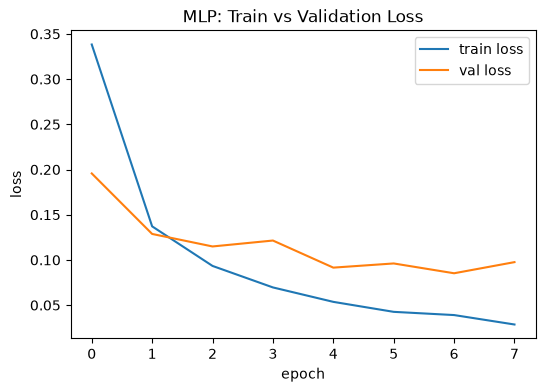

In [ ]:
#Plot the training loss and validation loss for the MLP model over the epochs. This allows us to visualize the training process and assess how well the model is learning. A decreasing training loss indicates that the model is fitting the training data, while a decreasing validation loss indicates that the model is generalizing well to unseen data.
plt.figure(figsize=(6, 4))
plt.plot(mlp_history['train_loss'], label='train loss')
plt.plot(mlp_history['val_loss'], label='val loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('MLP: Train vs Validation Loss')
plt.legend()
plt.show()

## 6. Add a CNN variant

Replace flatten+MLP with a couple `Conv2d` + pooling layers. Compare accuracy and training time against the MLP.

In [ ]:
#Define a convolutional neural network (CNN) with two convolutional layers, two max pooling layers, and two fully connected layers. The first convolutional layer has 32 filters, the second convolutional layer has 64 filters, and the output layer has 10 neurons (one for each class in the MNIST dataset). We will use ReLU activation functions for the hidden layers.
class CNN(nn.Module):
    #Initialize the CNN class. The constructor takes no arguments and initializes the convolutional and fully connected layers.
    def __init__(self):
        #Call the constructor of the parent class (nn.Module) to initialize the CNN class.
        super().__init__()
        #Define the convolutional and fully connected layers. The first convolutional layer takes an input of size 1 (grayscale image) and outputs 32 filters, the second convolutional layer takes an input of size 32 and outputs 64 filters. The max pooling layers reduce the spatial dimensions of the feature maps by a factor of 2. The first fully connected layer takes an input of size 64 * 7 * 7 (the size of the feature maps after the convolutional and pooling layers) and outputs 128 neurons. The second fully connected layer takes an input of size 128 and outputs 10 neurons (one for each class in the MNIST dataset).
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
    #Define the forward pass of the CNN. The forward method takes an input tensor x and passes it through the convolutional and pooling layers, followed by the fully connected layers. ReLU activation functions are applied to the outputs of the convolutional and first fully connected layers. The output of the second fully connected layer is returned as the final output of the network.
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

#Create an instance of the CNN class and move it to the device (GPU or CPU) for training. The to(device) method is used to move the model to the specified device.
cnn = CNN().to(device)

#Train the CNN model for 5 epochs and record the training time. The train_model function is called with the CNN model, training data loader, validation data loader, and the number of epochs as arguments. The training time is calculated by measuring the time before and after the training process.
cnn_start = time.time()
cnn_history = train_model(cnn, train_loader, val_loader, epochs=5)
cnn_train_time = time.time() - cnn_start
#Print the total training time for the CNN model. This provides information on how long it took to train the model for the specified number of epochs, which can be useful for comparing the efficiency of different models or training configurations.
print(f'CNN training time: {cnn_train_time:.1f}s')

#Print the best validation accuracy achieved by the MLP and CNN models, along with the corresponding training times. This allows us to compare the performance of the two models in terms of accuracy and training efficiency.
print(f"MLP best val acc: {max(mlp_history['val_acc']):.4f} in {mlp_train_time:.1f}s")
print(f"CNN best val acc: {max(cnn_history['val_acc']):.4f} in {cnn_train_time:.1f}s")

Epoch 1/5  train_loss=0.1741  val_loss=0.0856  val_acc=0.9730


Epoch 2/5  train_loss=0.0513  val_loss=0.0524  val_acc=0.9845


Epoch 3/5  train_loss=0.0339  val_loss=0.0518  val_acc=0.9857


Epoch 4/5  train_loss=0.0240  val_loss=0.0421  val_acc=0.9883


Epoch 5/5  train_loss=0.0193  val_loss=0.0379  val_acc=0.9898
CNN training time: 60.1s
MLP best val acc: 0.9738 in 49.9s
CNN best val acc: 0.9898 in 60.1s


## 7. Evaluate

Accuracy + confusion matrix across the 10 digits. Which digits get confused with each other most?

CNN test accuracy: 0.9929
[[ 977    0    0    1    0    0    0    0    1    1]
 [   0 1133    0    0    0    0    0    2    0    0]
 [   1    1 1026    0    1    0    0    2    1    0]
 [   0    0    0 1005    0    1    0    1    3    0]
 [   0    0    0    0  981    0    0    0    0    1]
 [   2    0    0    4    0  880    1    1    2    2]
 [   4    3    1    0    1    1  945    0    3    0]
 [   0    1    3    0    0    0    0 1022    1    1]
 [   1    0    2    1    0    0    0    0  970    0]
 [   0    0    0    1    7    3    0    4    4  990]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
          

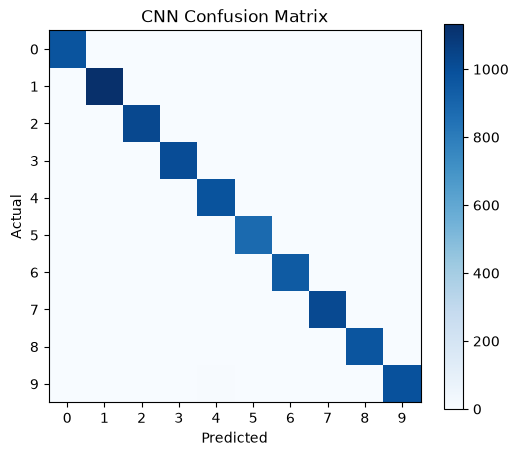

In [ ]:
#Evaluate the CNN model on the test dataset and compute the confusion matrix and classification report. The model is set to evaluation mode, and predictions are made on the test dataset without computing gradients. The predicted labels and true labels are collected, and the test accuracy is calculated. The confusion matrix and classification report provide insights into the model's performance across different classes.
from sklearn.metrics import confusion_matrix, classification_report

#Cnn model is set to evaluation mode, which disables certain layers (like dropout and batch normalization) from behaving differently during training and evaluation. This ensures that the model's predictions are consistent and reliable during evaluation.
cnn.eval()
all_preds = []
all_labels = []
#No gradients are computed during evaluation, which saves memory and computation time. The model's predictions are made on the test dataset, and the predicted labels and true labels are collected for further analysis.
with torch.no_grad():
    #Iterate over the test data loader, which provides batches of images and labels. For each batch, perform the following steps:
    for images, labels in test_loader:
        images = images.to(device)
        outputs = cnn(images)
        preds = outputs.argmax(dim=1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)

#Concatenate the predicted labels and true labels from all batches into single tensors, and convert them to NumPy arrays for further analysis. This allows us to compute the overall test accuracy, confusion matrix, and classification report for the entire test dataset.
all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

#Compute the test accuracy by comparing the predicted labels with the true labels. The test accuracy is calculated as the mean of the boolean array resulting from the comparison, which indicates the proportion of correct predictions made by the model on the test dataset.
test_acc = (all_preds == all_labels).mean()
print(f'CNN test accuracy: {test_acc:.4f}')

#Compute the confusion matrix and classification report for the CNN model's predictions on the test dataset. The confusion matrix provides a summary of the model's performance by showing the number of correct and incorrect predictions for each class, while the classification report provides precision, recall, and F1-score metrics for each class.
cm = confusion_matrix(all_labels, all_preds)
print(cm)
print(classification_report(all_labels, all_preds))

#Plot the confusion matrix for the CNN model's predictions on the test dataset. The confusion matrix is visualized using a heatmap, where the color intensity represents the number of predictions for each class. The x-axis represents the predicted classes, and the y-axis represents the actual classes. This visualization allows us to easily identify which classes are being confused by the model and assess its overall performance.
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('CNN Confusion Matrix')
plt.xticks(range(10))
plt.yticks(range(10))
plt.show()

## 8. Regularization experiment

Add dropout or weight decay. Observe the change in the train/val gap.

Epoch 1/5  train_loss=0.2500  val_loss=0.0699  val_acc=0.9798


Epoch 2/5  train_loss=0.0857  val_loss=0.0533  val_acc=0.9848


Epoch 3/5  train_loss=0.0634  val_loss=0.0477  val_acc=0.9878


Epoch 4/5  train_loss=0.0511  val_loss=0.0396  val_acc=0.9882


Epoch 5/5  train_loss=0.0434  val_loss=0.0434  val_acc=0.9870
CNN train/val loss gap: -0.0186
CNN+dropout train/val loss gap: -0.0000


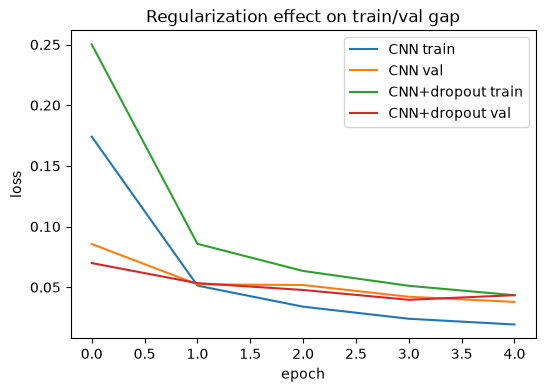

In [ ]:
#Define a convolutional neural network (CNN) with dropout regularization. The CNNDropout class inherits from nn.Module and has the same architecture as the CNN class, but with an additional dropout layer after the first fully connected layer. The dropout layer randomly zeroes out a fraction of its inputs during training, which helps prevent overfitting and improves generalization.
class CNNDropout(nn.Module):
    #Initialize the CNNDropout class. The constructor takes a dropout rate as an argument and initializes the convolutional, pooling, dropout, and fully connected layers.
    def __init__(self, dropout=0.5):
        #Call the constructor of the parent class (nn.Module) to initialize the CNNDropout class.
        super().__init__()
        #Define the convolutional, pooling, dropout, and fully connected layers. The first convolutional layer takes an input of size 1 (grayscale image) and outputs 32 filters, the second convolutional layer takes an input of size 32 and outputs 64 filters. The max pooling layers reduce the spatial dimensions of the feature maps by a factor of 2. The dropout layer randomly zeroes out a fraction of its inputs during training, with the dropout rate specified by the dropout argument. The first fully connected layer takes an input of size 64 * 7 * 7 (the size of the feature maps after the convolutional and pooling layers) and outputs 128 neurons. The second fully connected layer takes an input of size 128 and outputs 10 neurons (one for each class in the MNIST dataset).
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    #Define the forward pass of the CNNDropout. The forward method takes an input tensor x and passes it through the convolutional and pooling layers, followed by the fully connected layers. ReLU activation functions are applied to the outputs of the convolutional and first fully connected layers. The dropout layer is applied after the first fully connected layer during training, which randomly zeroes out a fraction of its inputs. The output of the second fully connected layer is returned as the final output of the network.
    def forward(self, x):
        #Pass the input tensor x through the first convolutional layer, apply ReLU activation, and then apply max pooling to reduce the spatial dimensions of the feature maps. This process extracts features from the input images while reducing their size.
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

#Train the CNN model with dropout regularization for 5 epochs and record the training time. The train_model function is called with the CNNDropout model, training data loader, validation data loader, and the number of epochs as arguments. The training time is calculated by measuring the time before and after the training process.
cnn_dropout = CNNDropout(dropout=0.5).to(device)
dropout_history = train_model(cnn_dropout, train_loader, val_loader, epochs=5)

#Calculate the train/validation loss gap for the CNN and CNN+dropout models. The gap is computed as the difference between the final training loss and the final validation loss for each model. A smaller gap indicates better generalization, while a larger gap may suggest overfitting.
cnn_gap = cnn_history['train_loss'][-1] - cnn_history['val_loss'][-1]
dropout_gap = dropout_history['train_loss'][-1] - dropout_history['val_loss'][-1]
print(f'CNN train/val loss gap: {cnn_gap:.4f}')
print(f'CNN+dropout train/val loss gap: {dropout_gap:.4f}')

#Plot the training and validation loss for the CNN and CNN+dropout models over the epochs. This allows us to visualize the effect of dropout regularization on the train/validation loss gap. A smaller gap indicates better generalization, while a larger gap may suggest overfitting. The plot includes labels for each model's training and validation loss, as well as axis labels, a legend, and a title.
plt.figure(figsize=(6, 4))
plt.plot(cnn_history['train_loss'], label='CNN train')
plt.plot(cnn_history['val_loss'], label='CNN val')
plt.plot(dropout_history['train_loss'], label='CNN+dropout train')
plt.plot(dropout_history['val_loss'], label='CNN+dropout val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.title('Regularization effect on train/val gap')
plt.show()